In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.columns

Index(['label', 'message'], dtype='str')

In [5]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
df[df["label"] == "spam"].head(10)

,label,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
19,spam,England v Macedonia - dont miss the goals/team...
34,spam,Thanks for your subscription to Ringtone UK yo...
42,spam,07732584351 - Rodger Burns - MSG = We tried to...


In [8]:
df["message_length"] = df["message"].str.len()

In [9]:
df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [10]:
df.groupby("label")["message_length"].mean()

label
ham      71.482487
spam    138.670683
Name: message_length, dtype: float64

In [11]:
df["message"].str.lower().str.contains("free").sum()

np.int64(265)

In [12]:
df.groupby("label")["message"].apply(
    lambda messages: messages.str.lower().str.contains("free").sum()
)

label
ham      66
spam    199
Name: message, dtype: int64

## Initial observations

- The dataset contains both spam and legitimate messages.
- Spam messages appear to contain certain words such as "free" and "winner" more frequently.
- 265 messages contain the word "free":
  - 66 ham
  - 199 spam
- The presence of "free" appears to be a useful signal, but it cannot be used as a definitive spam rule because legitimate messages can also contain it.

<Axes: xlabel='label'>

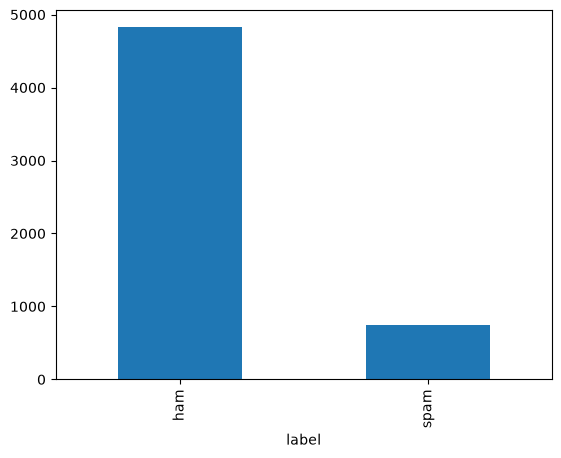

In [13]:
df["label"].value_counts().plot(kind="bar")

In [14]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

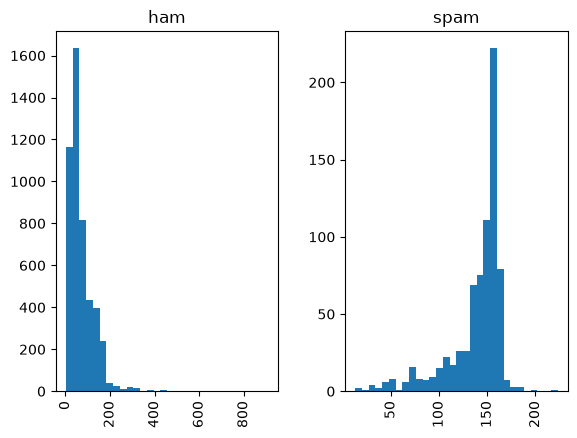

In [15]:
df.hist(column="message_length", by="label", bins=30)

In [16]:

# Learning how to use CountVectorizer
# X = what we give the model
# y = what we want the model to predict
from sklearn.feature_extraction.text import CountVectorizer

messages = [
    "free prize",
    "free money",
    "hello friend"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(messages)
vectorizer.get_feature_names_out()

X.toarray()

array([[1, 0, 0, 0, 1],
       [1, 0, 0, 1, 0],
       [0, 1, 1, 0, 0]])

In [17]:
# Applying it to our real SMS dataset
# X = what we give the model (number of messages)
# y = what we want the model to predict
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["message"])
X.shape


(5572, 8713)

In [18]:
print(df["message"].iloc[0])

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [19]:
print(X[0].toarray())

[[0 0 0 ... 0 0 0]]


In [20]:
# Defining y, what we want the model to predict
y = df["label"]
y.head()

0     ham
1     ham
2    spam
3     ham
4     ham
Name: label, dtype: str

Training vs. testing

We don't want to give the model every message and then ask it how well it performs on those same messages. That would be like giving you the answers while studying and then testing you with the exact same questions.

                    5,572 messages
                         │
              ┌──────────┴──────────┐
              │                     │
           Training              Testing
          ~80% (~4,458)         ~20% (~1,114)
              │                     │
       Model learns from      We evaluate it on
          these messages       messages it hasn't seen

The training set is what the model learns from. The test set is our final exam.

And there's an important detail: we'll make sure the ham/spam proportions remain roughly similar in both sets. This is called stratification

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4457, 8713)
(1115, 8713)


In [22]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train) # X_train = the messages in numerical array, y_train = the correct answers



,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['ham','spam']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 8713)","[[ 0., 0., 1.,..., 1., 0., 1.], [10.,21., 0.,..., 0., 1., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 8713)","[[-10.98,-10.98,-10.28,...,-10.28,-10.98,-10.28], [ -7.63, -6.94,-10.03,...,-10.03, -9.34,-10.03]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8713


In [23]:
predictions = model.predict(X_test)
predictions[:20]

array(['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham'], dtype='<U4')

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(accuracy)

0.9829596412556054


In [25]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[955,  11],
       [  8, 141]])

Two metrics that are particularly useful for spam detection:

Precision → "When the model says spam, how often is it right?"

Recall → "Of all the actual spam, how much did the model catch?"

1. Precision "Can I trust a spam prediction?": 

Our model predicted spam for:

141 actual spam messages and 11 ham messages

So it made 152 spam predictions total. Precision asks:

"Of those 152 messages I called spam, how many really were spam?"

So: 141 ÷ (141 + 11) ≈ 92.8%. In plain English: "When our model says "this is spam," it's correct about 93% of the time."

2. Recall "How much spam did we catch?"

There were: 141 spam messages caught, 8 spam messages missed

So there were 149 actual spam messages. Recall asks:

"Of all the spam that existed, how much did our model find?"

So: 141 ÷ (141 + 8) ≈ 94.6%. In plain English: "Our model catches about 95% of the spam."


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.93      0.95      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



For this case, the vectorizer saw the entire dataset—including the test messages—when creating its vocabulary.

This is called data leakage.

It doesn't mean our model is useless. It's actually a great learning result. But for a proper ML project, we want the test set to remain completely unseen until evaluation.

We'll redo the vectorization correctly, then train the same Naive Bayes model again and compare the results.

The nice thing is that this will introduce an important ML concept: pipelines.

In [27]:
from sklearn.model_selection import train_test_split

X_text = df["message"] # THE MESSAGES THEMSELVES
y = df["label"] # THE HAM/SPAM LABELS

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_text.shape)
print(X_test_text.shape)

(4457,)
(1115,)


If a word appears only in the test data, however, the vectorizer hasn't learned it. That word is simply ignored when transforming the test message. That's intentional, since we don't want the test data to teach the model anything.

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(X_train.shape)
print(X_test.shape)

(4457, 7668)
(1115, 7668)


In [29]:
# Train the model again, now with a smaller dataset containing only training data
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train) # X_train = the messages in numerical array, y_train = the correct answers

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U4](2,)","['ham','spam']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7668)","[[ 0., 0., 1.,..., 1., 0., 1.], [10.,21., 0.,..., 0., 1., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7668)","[[-10.96,-10.96,-10.27,...,-10.27,-10.96,-10.27], [ -7.59, -6.89, -9.98,..., -9.98, -9.29, -9.98]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7668


In [30]:
# "Here are new messages the model hasn't seen. Based on what you learned during training, tell me whether each one is ham or spam."
predictions = model.predict(X_test)

# Show the predictions of the first 20 never seen before test messages
predictions[:20]

array(['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham'], dtype='<U4')

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2%}")

confusion_matrix(y_test, predictions)

Accuracy: 98.74%


array([[964,   2],
       [ 12, 137]])

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



Metric    | Score | Interpretation
Precision |	0.99  | When it says spam, it's right ~99% of the time
Recall    | 0.92  |	It catches ~92% of actual spam
F1        | 0.95  |	Strong balance between precision and recall
Support	  | 149   |	149 spam messages in the test set


- What is TF-IDF? -

CountVectorizer essentially asks: "How many times does this word appear?".
TF-IDF asks a slightly smarter question: "How important is this word to this particular message compared with how common it is across all messages?"

For example, words like: "the, you, and" appear in lots of messages, so they aren't very useful for distinguishing spam. A word like: "winner, claim, prize" might be much more informative.

TF-IDF gives relatively more weight to words that help distinguish documents.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4457, 7668)
(1115, 7668)


In [37]:
from sklearn.naive_bayes import MultinomialNB

tfidf_model = MultinomialNB()
tfidf_model.fit(X_train_tfidf, y_train)

tfidf_predictions = tfidf_model.predict(X_test_tfidf)
tfidf_predictions[:20]

array(['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham'], dtype='<U4')

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

tfidf_accuracy  = accuracy_score(y_test, tfidf_predictions)
print(f"TF-IDF Accuracy: {tfidf_accuracy:.2%}")

confusion_matrix(y_test, tfidf_predictions)

TF-IDF Accuracy: 96.05%


array([[966,   0],
       [ 44, 105]])

CountVectorizer + Naive Bayes → 98.74% 
TF-IDF + Naive Bayes          → 96.05% 

This means that the two approaches generate different results, with one model being better than the other. We tested both instead of just assuming one approach would work better.

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

ngram_vectorizer = CountVectorizer(ngram_range=(1, 2))

X_train_ngram = ngram_vectorizer.fit_transform(X_train_text)
X_test_ngram = ngram_vectorizer.transform(X_test_text)

print(X_train_ngram.shape)
print(X_test_ngram.shape)

(4457, 42696)
(1115, 42696)


In [45]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

ngram_model = MultinomialNB()
ngram_model.fit(X_train_ngram, y_train)

ngram_predictions = ngram_model.predict(X_test_ngram)

ngram_accuracy = accuracy_score(y_test, ngram_predictions)
print(f"N-gram Accuracy: {ngram_accuracy:.2%}")

N-gram Accuracy: 98.21%


In [46]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, ngram_predictions)

array([[964,   2],
       [ 18, 131]])

In [47]:
# Testing it with messages we write ourselves

test_messages = [
    "Congratulations! You have won a free vacation. Claim your prize now!",
    "Hey, are we still meeting for dinner tonight?",
    "URGENT! You have been selected to receive $5000. Call now!",
    "Can you send me the report when you get a chance?",
    "FREE entry into our competition! Text WIN to 80085 now!"
]

# For the new batch of data, we shouldn't .fit() again, because our existing vectorizer already knows the vocabulary it learned from the training data. We want new messages interpreted using that same vocabulary.
new_messages_vectorized = vectorizer.transform(test_messages)

new_predictions = model.predict(new_messages_vectorized)

for message, prediction in zip(test_messages, new_predictions):
    print(f"{prediction.upper():5} | {message}")


SPAM  | Congratulations! You have won a free vacation. Claim your prize now!
HAM   | Hey, are we still meeting for dinner tonight?
SPAM  | URGENT! You have been selected to receive $5000. Call now!
HAM   | Can you send me the report when you get a chance?
SPAM  | FREE entry into our competition! Text WIN to 80085 now!


In [48]:
tricky_messages = [
    "The store is offering a free coffee with every purchase today.",
    "You are the winner of our office raffle! Please stop by my desk.",
    "Feel free to call me when you arrive.",
    "Don't forget to claim your free birthday dessert.",
    "Your bank statement is ready to view online.",
    "URGENT! Claim your FREE prize now by calling 08001234567.",
    "Congratulations! You have been selected for a cash reward. Reply YES.",
    "You have won a £1000 gift voucher. Text WIN to 80082 now.",
    "Exclusive offer! Get 90% off today only. Click here to claim.",
    "FINAL NOTICE: Your reward expires today. Call now!"
]

tricky_predictions = model.predict(
    vectorizer.transform(tricky_messages)
)

for message, prediction in zip(tricky_messages, tricky_predictions):
    print(f"{prediction.upper():5} | {message}")

SPAM  | The store is offering a free coffee with every purchase today.
HAM   | You are the winner of our office raffle! Please stop by my desk.
HAM   | Feel free to call me when you arrive.
SPAM  | Don't forget to claim your free birthday dessert.
HAM   | Your bank statement is ready to view online.
SPAM  | URGENT! Claim your FREE prize now by calling 08001234567.
SPAM  | Congratulations! You have been selected for a cash reward. Reply YES.
SPAM  | You have won a £1000 gift voucher. Text WIN to 80082 now.
SPAM  | Exclusive offer! Get 90% off today only. Click here to claim.
SPAM  | FINAL NOTICE: Your reward expires today. Call now!


What I guesses the model would say:

SPAM
SPAM
HAM
SPAM
HAM
SPAM
SPAM
SPAM
SPAM
SPAM

In [49]:
tricky_vectors = vectorizer.transform(tricky_messages)

probabilities = model.predict_proba(tricky_vectors)

for message, probs in zip(tricky_messages, probabilities):
    print(message)
    print(f"Ham:  {probs[0]:.2%}")
    print(f"Spam: {probs[1]:.2%}")
    print()

The store is offering a free coffee with every purchase today.
Ham:  16.64%
Spam: 83.36%

You are the winner of our office raffle! Please stop by my desk.
Ham:  85.69%
Spam: 14.31%

Feel free to call me when you arrive.
Ham:  98.18%
Spam: 1.82%

Don't forget to claim your free birthday dessert.
Ham:  4.56%
Spam: 95.44%

Your bank statement is ready to view online.
Ham:  80.98%
Spam: 19.02%

URGENT! Claim your FREE prize now by calling 08001234567.
Ham:  0.00%
Spam: 100.00%

Congratulations! You have been selected for a cash reward. Reply YES.
Ham:  0.00%
Spam: 100.00%

You have won a £1000 gift voucher. Text WIN to 80082 now.
Ham:  0.00%
Spam: 100.00%

Exclusive offer! Get 90% off today only. Click here to claim.
Ham:  1.96%
Spam: 98.04%

FINAL NOTICE: Your reward expires today. Call now!
Ham:  0.00%
Spam: 100.00%



In [51]:
test_probabilities = model.predict_proba(X_test)

spam_probabilities = test_probabilities[:, 1]

print(spam_probabilities[:10])

[4.91581714e-06 8.45581173e-17 1.16633731e-10 1.00000000e+00
 1.01226136e-05 9.38066487e-17 1.85659269e-07 4.85891046e-08
 6.97120532e-24 4.66633182e-09]


In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.70, 0.80, 0.90, 0.95]

for threshold in thresholds:
    threshold_predictions = (spam_probabilities >= threshold).astype(int)

    # Convert actual labels to 0 = ham, 1 = spam
    y_test_binary = (y_test == "spam").astype(int)

    precision = precision_score(y_test_binary, threshold_predictions)
    recall = recall_score(y_test_binary, threshold_predictions)
    f1 = f1_score(y_test_binary, threshold_predictions)

    print(f"Threshold: {threshold:.0%}")
    print(f"Precision: {precision:.2%}")
    print(f"Recall:    {recall:.2%}")
    print(f"F1:        {f1:.2%}")
    print()

Threshold: 50%
Precision: 98.56%
Recall:    91.95%
F1:        95.14%

Threshold: 70%
Precision: 99.24%
Recall:    87.92%
F1:        93.24%

Threshold: 80%
Precision: 99.24%
Recall:    87.92%
F1:        93.24%

Threshold: 90%
Precision: 99.24%
Recall:    87.92%
F1:        93.24%

Threshold: 95%
Precision: 99.24%
Recall:    87.25%
F1:        92.86%

